In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
X, y = mnist.data, mnist.target

There are 70,000 images, and each image has 784 features. This is because
each image is 28 × 28 pixels, and each feature simply represents one pixel’s
intensity, from 0 (white) to 255 (black)

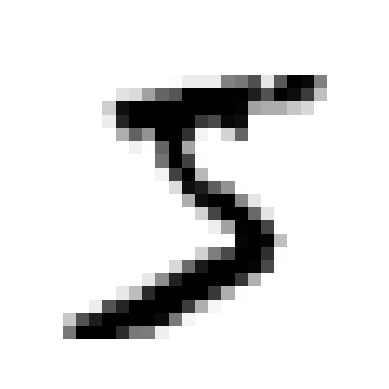

In [3]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Why k-neighbours here is good?
MNIST is a “similar things are near each other” problem, and KNN directly exploits that — no modeling assumptions needed.

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

In [6]:
knn_clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [7]:
from sklearn.metrics import accuracy_score

y_pred = knn_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9688

Hyper param tuning 
n_neighbors
Controls bias vs variance
Small = noisy, large = smoother

weights (uniform vs distance)
Distance usually better → closer points matter more

In [9]:
for n in range(3, 11):
    knn_clf = KNeighborsClassifier(n_neighbors=n, weights="uniform")
    knn_clf.fit(X_train, y_train)
    y_pred = knn_clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_neighbors={n}, weights=uniform, accuracy={acc:.4f}")

n_neighbors=3, weights=uniform, accuracy=0.9705
n_neighbors=4, weights=uniform, accuracy=0.9682
n_neighbors=5, weights=uniform, accuracy=0.9688
n_neighbors=6, weights=uniform, accuracy=0.9677
n_neighbors=7, weights=uniform, accuracy=0.9694
n_neighbors=8, weights=uniform, accuracy=0.9670
n_neighbors=9, weights=uniform, accuracy=0.9659
n_neighbors=10, weights=uniform, accuracy=0.9665


When you increase n_neighbors
You’re averaging over more points
That includes farther (less relevant) points
→ can blur the decision
Why weights='distance' helps
Gives more importance to closer neighbors
Reduces the influence of those farther ones you added

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for n in range(5, 11):
    knn_clf = KNeighborsClassifier(n_neighbors=n, weights="distance")
    knn_clf.fit(X_train, y_train)
    y_pred = knn_clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_neighbors={n}, weights=distance, accuracy={acc:.4f}")

n_neighbors=5, weights=distance, accuracy=0.9691
n_neighbors=6, weights=distance, accuracy=0.9709
n_neighbors=7, weights=distance, accuracy=0.9700
n_neighbors=8, weights=distance, accuracy=0.9706
n_neighbors=9, weights=distance, accuracy=0.9673
n_neighbors=10, weights=distance, accuracy=0.9684
n_neighbors=11, weights=distance, accuracy=0.9678
n_neighbors=12, weights=distance, accuracy=0.9678
n_neighbors=13, weights=distance, accuracy=0.9665
n_neighbors=14, weights=distance, accuracy=0.9655
n_neighbors=15, weights=distance, accuracy=0.9647
n_neighbors=16, weights=distance, accuracy=0.9648


KeyboardInterrupt: 

Conclusion:
We achieved about 97%+ test accuracy in two good settings:
- n_neighbors = 3, weights = "uniform" (best local voting)
- n_neighbors = 8, weights = "distance" (more neighbors, but closer points get higher influence)

This implies MNIST is strongly locality-driven: both a small-neighbor hard vote and a larger-neighbor distance-weighted vote work well, as long as nearby samples are emphasized.